<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_full_fine_tune_tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **Note:** If you're running in Google Colab, make sure to enable GPU usage by going to Runtime -> Change runtime type -> select GPU.

[Source Code](https://github.com/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_full_fine_tune_tutorial.ipynb) | [Walkthrough video on YouTube](https://youtu.be/2hoNAr-id-E)

## Overview

Why fine-tune a Small Language Model (SLM)?

Because we want small model for a specific task (e.g. don't to pay API credits or leak our data online).

If we have our own model... we can run it anywhere and everywhere we like.

TK definition - what is a small language model?

## What we're cooking

We're going to build a SLM (Small Language Model) to extract food and drink items from text.

Why?

This is often referred to as *structured data extraction**.

It's a very common problem throughout many businesses.

For example, say you were getting a large volume of emails in plain text and needed to extract customer details from them.

Or you wanted to analyze a large number of news reports for specific details.

Or in our case, say you were building an app like [Nutrify](https://nutrify.app) and you wanted to filter a large set of image captions for food/drink items.

Essentially, structured data extraction can be used anywhere you have unstructured data such as raw notes or plain text and would like to turn it into structured information you can analyze with Google Sheets or pandas or other data analysis tool.

<figure style="text-align: center;">
    <!-- figtemplate -->
    <img src="https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-fine-tune-llm/00-learn-hf-fine-tune-llm-overview.png"
     alt="
The FoodExtract project demonstrates a structured data extraction workflow where a plain text description of a meal—including beef mince, rice, sauce, pickles, peppers, and water—is fed into a fine-tuned Gemma 3 270M model to be converted into a precise JSON output. This process transforms the unstructured input into organized key-value pairs, categorizing the items into 'food_items' and 'drink_items' while assigning specific 'tags' and a 'food_or_drink' status." 
     style="width: 100%; max-width: 900px; height: auto;"/>
     <figcaption>We're going to fine-tune the Gemma 3 270M model for structured data extraction from plain text.</figcaption>
</figure>

## How to fine-tune an LLM model

There are several ways to fine-tune an LLM including reinforcement learning (RL) and Supervised Fine-tuning (SFT).

We are going to do SFT because it's the most straightforward. 

Basically SFT = give samples of inputs and outputs and the model learns to map a given input to a given output.

For example if our goal was to extract names: 

- Input: Hello my name is Daniel
- Output: Daniel

Note:

* Our inputs can be *any* kind of input string.
* Our outputs will be fine-tuned to conform to a structured data pattern.

::: {.callout-tip}
## LLM Fine-tuning Mindset

In LLM world, data inputs are tokens and data outputs are tokens.

A token is a numerical representation of some kind of data.

Computers like numbers (not images, text, videos, etc).

Everything must be turned into numbers.

And data = a very broad term.

It could be text, images, video (series of images), audio, DNA sequences, Excel spreadsheets, you name it.

The goal of the LLM is to be given an input sequence of tokens and then predict the following tokens.

So with this mindset, you can think of any problem as **tokens in, tokens out**.

Ask yourself: *What tokens do I want to put in and what tokens do I want my model to return?*

In our case, we want to put in almost any string input. And we want to get back structured information specifically related to food and drinks.

This a very specific use case, however, the beauty of LLMs being so general is that you can apply this **tokens in, tokens out** mindset to almost anything.

If you've got an existing dataset (no problem if you don't, you can create one, let me know if you'd like a guide on this), chances are, you can fine-tune an LLM to do pretty well on it.
:::

## Ingredients

We're going to start with:

| Start | Item | Link | Notes |
|---|---|---|---|
| 1 | Base Model | [Gemma-3-270M](https://huggingface.co/google/gemma-3-270m-it) | We will fine-tune this model to perform our specific task. |
| 2 | Dataset | [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) | A pre-baked dataset to extract foods and drinks from text. |

And we're going to work towards building:

| Build | Item | Link | Notes |
|---|---|---|---|
| 3 | Training code | — | Hugging Face Transformers + TRL inside this notebook. |
| 4 | Eval code | — | Inside this notebook. |
| 5 | Fine-tuned model | [FoodExtract-gemma-3-270m-fine-tune-v1](https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1) | The FoodExtract model we'll end up with after fine-tuning the base model. |
| 6 | Demo | [FoodExtract-v1](https://huggingface.co/spaces/mrdbourke/FoodExtract-v1) | An interactive demo to try out the model and share with others. |

## Method

1. Download model - [Hugging Face `transformers`](https://huggingface.co/docs/transformers/index)
2. Download dataset - [Hugging Face `datasets`](https://huggingface.co/docs/datasets/en/index)
3. Inspect dataset - Hugging Face `datasets` 
4. Train model on dataset - [Hugging Face `trl`](https://huggingface.co/docs/trl/en/index) (TRL = Transformers Reinforcement Learning)
5. Eval model - look at a bunch of samples + add metrics to compare to the original labelling model
6. Create an interactive demo - Hugging Face `gradio` 
7. Bonus: Make the demo public so other people can use it - Hugging Face Spaces

## Fine-tuning LLM vs RAG

* Fine-tuning = To do a very specific task, e.g. structured data extraction.
    * An example would be you're an insurance company who gets 10,000 emails a day and you want to extract structured data directly from these emails to JSON.
* RAG = You want to inject custom knowledge into an LLM.
    * An example would be you're an insurance company wanting to send *automatic* responses to people but you want the responses to include information from your own docs.

## Why fine-tune your own model?

1. Own the model, can run on own hardware
2. Our task is simple enough to just use a small language model
3. No API calls needed 
4. Can run in batch mode to get much faster inference than API calls
5. Model by default wasn't very good at our task but now since fine-tuning, is *very good* 

## Definitions

Some quick definitions of what we're doing.

* **Full fine-tuning** - All weights on the model are updated. Often takes longer and requires larger hardware capacity, however, if your model is small enough (e.g. 270M parameter or less), you can often do full fine-tuning.
* **LORA fine-tuning** (also known as partial fine-tuning) - [Low Rank Adaptation](https://arxiv.org/abs/2106.09685) or training a small adapter to attach to your original model. Requires significantly less resources but [can perform on par with full fine-tuning](https://thinkingmachines.ai/blog/lora/). 
* **SLM (Small Language Model)** - A subjective definition but to me a Small Language Model is a model with under 1B parameters, with added bonus for being under 500M parameters. Less parameters generally means less performance. However, when you have a specific task, SLMs often shine because they can be tailored for that specific task. If your task is "I want to create a chatbot capable of *anything*", you'll generally want the biggest model you can reasonably serve. If your task is "I want to extract some structured data from raw text inputs", you'll probably be surprised how well a SLM can perform.

## Import dependencies

> **Note:** If you're in Google Colab, you may have to install `trl`, `accelerate` and `gradio`.

For Google Colab:

```python
!pip install trl accelerate gradio
```


In [20]:
import transformers 
import trl # trl = Transformers Reinforcement Learning -> https://github.com/huggingface/trl 
import datasets 
import accelerate

import gradio as gr

Now let's make sure we've got enough GPU memory.

In [21]:
# Check the amount of GPU memory available (we need at least ~16GB)
import torch

if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)
    
    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory
    
    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")
else:
    print("No CUDA GPU available")

GPU: NVIDIA GB10
Total Memory:     128524.03 MB | 128.52 GB
Allocated Memory: 1609.44 MB | 1.61 GB
Reserved Memory:  1623.20 MB | 1.62 GB
Free Memory:      126900.83 MB | 126.90 GB


## Setup Base Model 

The base model we'll be using is [`gemma-3-270m-it`](https://huggingface.co/google/gemma-3-270m-it/tree/main) (the `-it` stands for "Instruction-Tuned"). I've tried with the base model ([`gemma-3-270m`](https://huggingface.co/google/gemma-3-270m/tree/main)) as well and found fine-tuning each gives largely similar results.

It's the same architecture style as larger LLMs such as Gemini but at a *much* smaller scale.

This is why we refer to it as a "Small Language Model" or SLM.

We can load our model and its assosciated `tokenizer` using `transformers`.

:::{.callout-note}
A tokenizer converts raw string values into tokens which are numerical values our model can understand.

For example:

`tokenizer("Hello my name is Daniel")` -> `[2, 9259, 1041, 1463, 563, 13108]`
:::

In [22]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-3-270m-it" # note: "it" stands for "instruction tuned" which means the model has been tuned for following instructions

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype="auto",
    device_map="auto", # put the model on the GPU
    attn_implementation="eager" # could use flash_attention_2 but ran into issues... so stick with Eager for now
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


Let's test out the `tokenizer` on a demo string.

In [23]:
tokenizer("Hello my name is Daniel")

{'input_ids': [2, 9259, 1041, 1463, 563, 13108], 'attention_mask': [1, 1, 1, 1, 1, 1]}

We can pass these tokens directly too our model.

In [24]:
import torch 

outputs = model(torch.tensor(tokenizer("Hello my name is Daniel")["input_ids"]).unsqueeze(0).to("cuda"))
outputs.keys()

odict_keys(['logits', 'past_key_values'])

Feel free to inspec the `'logits'` and `'past_key_values'` our model outputs, however, these aren't necessarily valuable to use yet.

We'll need to convert them back into tokens so we can read them.

### Counting the number of parameters in our model

Let's confirm our model is a smaller model by counting the number of parameters in it.

In [35]:
def get_model_num_params(model):
    """
    Returns the number of trainable, non-trainable and total parameters of a PyTorch model.
    """
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params
    return {"trainable_params": trainable_params,
            "non_trainable_params": non_trainable_params,
            "total_params": total_params}

# Get parameters of our fine-tuned model
model_params = get_model_num_params(model)
print(f"Trainable parameters: {model_params['trainable_params']:,}")
print(f"Non-trainable parameters: {model_params['non_trainable_params']:,}")
print(f"Total parameters: {model_params['total_params']:,}")

Trainable parameters: 268,098,176
Non-trainable parameters: 0
Total parameters: 268,098,176


Alright, looks like our model has `268,098,176` parameters and all of them are trainable (they will be updated during training).

How does this compare to the number of parameters in our teacher model?

::: {.callout-note}
We'll see shortly that we used a larger model, [`openai/gpt-oss-120b`](https://huggingface.co/openai/gpt-oss-120b) to label our dataset with ground truth labels, we'll want to train our smaller model, `google/gemma-3-270m-it` to reproduce these labels.

This is a common workflow known as **distillation** or using a larger, more powerful model to teach a smaller, more efficient model to do the same task.
:::

In [ ]:
gpt_oss_120b_parameter_count = 120_000_000_000
gemma_3_270m_parameter_count = model_params['total_params']

parameter_ratio = gpt_oss_120b_parameter_count / gemma_3_270m_parameter_count

print(f"[INFO] Gemma 3 270M is {parameter_ratio:.2f}x smaller than gpt-oss-120b.")

[INFO] Gemma 3 270M is 447.60x smaller than gpt-oss-120b.


By fine-tuning Gemma 3 270M we distill the capabilities of a 120B parameter teacher model (`gpt-oss-120b`) into a model ~448x smaller.

## Getting a dataset

Our dataset is located here on Hugging Face under [`mrdbourke/FoodExtract-1k`](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k). 

It was created from image captions + random strings and then using `gpt-oss-120b` (a powerful open-source LLM) to do synthetic labelling into our target format.

For more on the dataset you can read the [README.md](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) file explaining it.

The main thing we are concerned about is that we want the input to our model to be the `"sequence"` column and the output to be the `"gpt-oss-120b-label-condensed"` column.

We'll explore these below.

In [25]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

[INFO] Number of samples in the dataset: 1420


Right now our dataset only has a training split (the default when no pre-defined splits are set).

We can break it into a training and test set later on.

For now, let's look at some random samples.

In [32]:
import ast
import random

def get_random_idx(dataset):
    """Returns a random integer index based on the number of samples in the dataset."""
    random_idx = random.randint(0, len(dataset)-1)
    return random_idx

random_idx = get_random_idx(dataset["train"])
random_sample = dataset["train"][random_idx]

example_input = random_sample["sequence"]
example_output = random_sample["gpt-oss-120b-label"]
example_output_condensed = random_sample["gpt-oss-120b-label-condensed"]

print(f"[INFO] Input:\n{example_input}\n")
print()
print(f"[INFO] Example structured JSON output (what we want to turn our raw texts into):\n")
print(ast.literal_eval(example_output)) # ast.literal_eval turns the string into JSON
print()
print(f"[INFO] Example output condensed (we'll train our model to predict the condensed output since it uses less tokens than JSON):\n")
print(example_output_condensed)

[INFO] Input:
This is a detailed screenshot from the game Europa Universalis IV: Rites of Man. To the left, a large expanse of blank tan-colored land extends, bordered by a green-hued coastline that wraps around its edges. The ocean occupies the center-left portion of the image, forming a natural boundary with the land. In the top right corner, another landmass is partially visible; it features both the same tan coloration and sections of exposed light brown earth, resembling dirt.

The screen is filled with various interface panels and elements. In the top-left corner, a shield icon is prominently displayed, accompanied by a horizontal row of small white text boxes containing information. Below this row, a long green information panel features several horizontal banners. To the right of this panel, a vertical stat information section is visible, with a blank chat box situated at its bottom.

Further down, a tiny map of the land is housed within a small box, flanked by buttons on both 

### Assigning tags to our samples

Because we'd like to use our model to potentially filter a large corpus of data, we get it to assign various tags to the text as well.

These tags could be anything we'd like to define. Because of the nature of our language model, it will be able to learn which tag it should assign to a given piece of text based on its training data.

We can use these tags later to find particular types of texts, for example, if we wanted specifically `nutrition_panel` related texts, we'd filter for the `np` tag.

:::{.callout-note}
We've shortened our tags here for interest of shorter generations, for example, `ingredient_list` gets shortened to `il`.

We don't necessarily have to do this.

For smaller sample sizes or more complicated labellings, we may actually want our model to generate the full tags so it has more context.

We'll leave this for experimentation.

Just remember, because of flexibility of language models, you can define the outputs how you'd like.
:::

The tags we'd like to assign are as follows.

In [27]:
# Our fine-tuned model will assign tags to text so we can easily filter them by type in the future
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient_list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}

### Format the dataset into LLM-style inputs/outputs

Right now we have examples of string-based inputs and structured outputs.

However, our LLMs generally want things in the format of: 

```
{"user": "Hello my name is Daniel",
 "assistant": "Hi Daniel, I'm an LLM"}
```

Where the `"user"` is the person giving the inputs (e.g. us typing into the model).

And the `"assistant"` is the model itself.

In other words, many models are setup in a way that they want structure around the intputs and outputs rather than just raw information.

:::{.callout-note title="Resource"}
For more on dataset formats, see the [TRL documentation for dataset formats](https://huggingface.co/docs/trl/en/dataset_formats).
:::

Let's remind ourselves what our raw samples look like.

In [28]:
random_sample

{'sequence': 'Aerial view of burning crops',
 'image_url': 'https://mixkit.imgix.net/videos/preview/mixkit-aerial-view-of-burning-crops-10300-0.jpg?q=80&auto=format%2Ccompress&w=460',
 'class_label': 'food',
 'source': 'coyo700m_dataset',
 'char_len': 28.0,
 'word_count': 5.0,
 'syn_or_real': 'real',
 'uuid': '31ea02e1-e95e-41d0-87ef-a07303fe3f9a',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None}

Ok, now we can make a helper function to turn our samples into conversation style.

In [29]:
def sample_to_conversation(sample):
    """Helper function to convert an input sample to conversation style."""
    return {
        "messages": [
            {"role": "user", "content": sample["sequence"]}, # Load the sequence from the dataset
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]} # Load the gpt-oss-120b generated label
        ]
    }

def sample_to_conversation(sample):
    """Helper function to convert an input sample to prompt-completion style."""
    return {
        "prompt": [
            {"role": "user", "content": sample["sequence"]}
        ],
        "completion": [
            {"role": "assistant", "content": sample["gpt-oss-120b-label-condensed"]}
        ]
    }

sample_to_conversation(random_sample)

{'prompt': [{'role': 'user', 'content': 'Aerial view of burning crops'}],
 'completion': [{'role': 'assistant',
   'content': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:'}]}

Wonderful!

Now let's map the `sample_to_conversation` helper function to our dataset with [`datasets.Dataset.map`](https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.map).

I've turned `batched=False` on here because when I set `batched=True` I was getting errors. You may want to try otherwise.

In [30]:
# Map our sample_to_conversation function to dataset 
dataset = dataset.map(sample_to_conversation,
                      batched=False)

dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

Notice how we now have a `"messages"` key in our dataset samples.

### Creating a train/test split

Time to turn our data into a training/test split.

Our model will be trained on the training split.

And then evaluated on the test split.

We keep the test split separate from our model's training so we can purposely evaluate our model on samples its never seen before.

To create a train/test split we can use the method [`datasets.Dataset.train_test_split`](https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.train_test_split) with `test_size=0.2` for an 80% train and 20% test subset.

In [31]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

Beautiful!

We've got a training/test split of our dataset.

How about we try our model on an example sample?

### Try the model with a pipeline

Let's write a quick helper function to format some text to turn it into message format.

In [13]:
def create_easy_sample(input):
    template = {"role": "user", "content": input}
    return template

create_easy_sample(input="Hello, I'm Daniel!")

{'role': 'user', 'content': "Hello, I'm Daniel!"}

Nice!

Now we can try out the model as a [`pipeline`](https://huggingface.co/docs/transformers/en/main_classes/pipelines#transformers.pipeline).

Hugging Face's `pipeline` is a simple entry point to using many different models.

It handles model loading and adds access to the specific tokenizer/preprocessor for a model.

In [14]:
from transformers import pipeline 

# Load model and use it as a pipeline
print(f"[INFO] Creating pipeline with model: {MODEL_NAME}\n")
pipe = pipeline("text-generation",
                model=model,
                tokenizer=tokenizer)

input_text = "Hi my name is Daniel. Please reply to me with a machine learning poem."
print(f"[INFO] This is the raw text input:\n{input_text}\n")

# Prepare the sample and tokenize
easy_sample = create_easy_sample(input=input_text)
input_prompt = pipe.tokenizer.apply_chat_template([easy_sample], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)
# Pass the prepared input prompt through the pipeline
default_outputs = pipe(input_prompt,
                       max_new_tokens=512,
                       disable_compile=True)

print(f"[INFO] This is the input prompt: {input_prompt}")
print(f"[INFO] Output from {MODEL_NAME}:")
print(default_outputs[0]["generated_text"][len(input_prompt):])

Device set to use cuda:0


[INFO] Creating pipeline with model: google/gemma-3-270m-it

[INFO] This is the raw text input:
Hi my name is Daniel. Please reply to me with a machine learning poem.

[INFO] This is the input prompt: <bos><start_of_turn>user
Hi my name is Daniel. Please reply to me with a machine learning poem.<end_of_turn>
<start_of_turn>model

[INFO] Output from google/gemma-3-270m-it:
Okay, Daniel, here's a machine learning poem in a simple, evocative style:

The code hums, a quiet song,
A symphony of logic strong.
It learns and grows, with patient grace,
Across the data's vast and wide.

From simple rules to complex schemes,
It builds a bridge of knowledge dreams.
A pattern emerges, clear and bright,
A future set, with guiding light.

It analyzes, it learns and refines,
A tireless engine, ever keen.
With every data point, it finds the key,
To unlock the secrets, wild and free.

So let the code take its flight,
And learn and grow, with all its might.
A machine learning, strong and true,
A future br

Example machine learning poem generated by Gemma 3 270:

```
Okay, Daniel, here's a machine learning poem. I've tried to capture a feeling of wonder and a bit of mystery.

The algorithm learns,
A silent, tireless quest.
Through data streams, it flows,
A symphony of thought.
Each point a new layer,
A learning bloom,
A future bright and clear.

It analyzes the data,
No single clue it knows.
It weaves a pattern true,
A story in the hue.
The world unfolds anew,
With subtle, complex view.

It's not just numbers,
But feeling, a soul.
A tapestry of grace,
A hopeful, vibrant space.
A learning, growing deep,
Secrets it will keep.
```

Not too bad!

But just beware, you will likely get different outputs each time.

This is because of nondeterminism of LLMs (for more on this concept and ways around it, refer to the blog post [*Defeating Nondeterminism in LLM Inference*](https://thinkingmachines.ai/blog/defeating-nondeterminism-in-llm-inference/) by Thinking Machines).

### What is a chat template?

Depending on the model you use, it may have been trained in a certain way to expect a certain kind of input.

The input formatter can be referred to as many things:

* A chat template
* A preprocessor
* Prefix tokens

In our case, we can view our models chat template with `tokenizer.chat_template`.

In [15]:
print(tokenizer.chat_template)

{{ bos_token }}
{%- if messages[0]['role'] == 'system' -%}
    {%- if messages[0]['content'] is string -%}
        {%- set first_user_prefix = messages[0]['content'] + '

' -%}
    {%- else -%}
        {%- set first_user_prefix = messages[0]['content'][0]['text'] + '

' -%}
    {%- endif -%}
    {%- set loop_messages = messages[1:] -%}
{%- else -%}
    {%- set first_user_prefix = "" -%}
    {%- set loop_messages = messages -%}
{%- endif -%}
{%- for message in loop_messages -%}
    {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
        {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
    {%- endif -%}
    {%- if (message['role'] == 'assistant') -%}
        {%- set role = "model" -%}
    {%- else -%}
        {%- set role = message['role'] -%}
    {%- endif -%}
    {{ '<start_of_turn>' + role + '
' + (first_user_prefix if loop.first else "") }}
    {%- if message['content'] is string -%}
        {{ message['content'] | trim }}


Notice how the chat template filters through different types of messages and gets them ready for use with a model?

### Try the model on one of our sequences

Okay, we've gotten the model to write a machine learning poem.

How about we get to perform on one of our samples?

In [16]:
# Get a random sample
random_idx = get_random_idx(dataset["train"])
random_train_sample = dataset["train"][random_idx]
raw_text_input = random_train_sample["sequence"]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["prompt"],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input (raw text):\n{raw_text_input}\n")
print(f"[INFO] Input (prompt formatted):\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input (raw text):
(((((((((((((((((((((((((((((((((((((((((((((((((.svg

[INFO] Input (prompt formatted):
<bos><start_of_turn>user
(((((((((((((((((((((((((((((((((((((((((((((((((.svg<end_of_turn>
<start_of_turn>model


[INFO] Output:
This is a very long string of characters. It's not a simple string, but rather a sequence of binary characters.



By default the model produces a fairly generic response.

This is expected and good.

It means the model has a good baseline understanding of language.

If it responded with pure garbage, we might have an uphill battle.

However, this response type is not what we want. We want our model to respond with **structured data** based on the input.

Good news is we can adjust the patterns in our model to do just that.

### Attempt 1: Let's try to prompt the model

We want a model to extract food and drink items from text.

By default the model will just reply to any text input with a generic response based on what it has seen in its training data.

However, we can try and get our ideal outputs via prompting.

So we'll write the following:

* A `prompt` to tnstruct our model to extract food and drink items.
* A helper function to format our `prompt` with a target sample.

In [17]:
prompt_instruction = """Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: <targ_input_text>"""

def update_input_message_content(input):
    """Helper function to format our prompt with target input text from a given message sample."""
    original_content = input["prompt"][0]["content"]
    new_content = prompt_instruction.replace("<targ_input_text>", original_content)

    new_input = [{"content": new_content,
                  "role": "user"}]
    
    return new_input

print(f'[INFO] Original content:\n{random_train_sample["prompt"][0]["content"]}')
print()
print(f'[INFO] New content with instructions in prompt:')
print(update_input_message_content(input=random_train_sample)[0]["content"])

[INFO] Original content:
(((((((((((((((((((((((((((((((((((((((((((((((((.svg

[INFO] New content with instructions in prompt:
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: (((((((((((((((((((((((((((((((((((((((((((((((((.svg


### Trying our formatted prompt with the model

Let's pass our instructional based prompt formatted with our target sample to see if the model can extract details in the format we'd like.

In [18]:
# Apply the chat template
updated_input_prompt = update_input_message_content(input=random_train_sample)

input_prompt = pipe.tokenizer.apply_chat_template(conversation=updated_input_prompt,
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, 
                       max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: (((((((((((((((((((((((((((((((((((((((((((((((((.svg<end_of_turn>
<start_of_turn>model


[INFO] Output:
```python
def extract_food_and_drink_items(image_caption):
    try:
        food_items = image_caption.split("\n")
        if not food_items:
            return []
      

Ok, for the following sample it looks like it kind of worked/kind of didn't (note: the sample you see output may be different, I'm using the following one for an example).

The input was (instructional prompt, formatted with our raw text string):

```
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list. 
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: Granola Raspberry & Vanilla: Ingredients include Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E. Contains Gluten. May contain Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy. Suitable for vegan diet. Nutrition Information: 8 servings per package, 45g per serving. Energy: 743kJ (177kcal), Protein: 3.5g, Fat: 4.4g (saturated: 0.6g), Carbohydrate: 29.2g (sugars: 7.2g), Dietary fibre: 3.3g, Sodium: 24mg. Store in cool, dry place out of direct sunlight. Price: $6.80.<end_of_turn>
<start_of_turn>model
```

And the output was:

```
food_items: ['Granola Raspberry & Vanilla', 'Whole Grain Oats', 'Puffed Rice', 'Glucose', 'Golden Syrup', 'Raw Sugar', 'Puffed Brown Rice', 'Raspberry Pieces', 'Sunflower Oil', 'Natural Vanilla Flavour', 'Tapioca Starch', 'Natural Flavour', 'Sea Salt', 'Vitamin E']
drink_items: ['cup of tea']
```

In this case, our model extracted a fair few of the food names.

But it also pulled out the drink `['cup of tea']` from the example (this wasn't in the input text).

This could be expected with such a small model.

Let's look at our ideal inputs and outputs for our given sample.

In [19]:
random_train_sample

{'sequence': '(((((((((((((((((((((((((((((((((((((((((((((((((.svg',
 'image_url': None,
 'class_label': 'not_food',
 'source': 'random-string-generation',
 'char_len': None,
 'word_count': None,
 'syn_or_real': 'syn',
 'uuid': 'a504003e-8952-4fdd-97bf-a5c2f4ae5441',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': '(((((((((((((((((((((((((((((((((((((((((((((((((.svg',
   'role': 'user'}],
 'completion': [{'content': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
   'role': 'assistant'}]}

In [20]:
# This is our input
print(f"[INFO] Raw text input:")
print(random_train_sample["prompt"][0]["content"])
print()

# This is our ideal output: 
print(f"[INFO] Ideal extraction output:")
print(random_train_sample["completion"][0]["content"])

[INFO] Raw text input:
(((((((((((((((((((((((((((((((((((((((((((((((((.svg

[INFO] Ideal extraction output:
food_or_drink: 0
tags: 
foods: 
drinks:


Your outputs might be different but continuing with the example we used above, we'd like ours to look like the following.

Raw input:

```
Granola Raspberry & Vanilla: Ingredients include Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E. Contains Gluten. May contain Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy. Suitable for vegan diet. Nutrition Information: 8 servings per package, 45g per serving. Energy: 743kJ (177kcal), Protein: 3.5g, Fat: 4.4g (saturated: 0.6g), Carbohydrate: 29.2g (sugars: 7.2g), Dietary fibre: 3.3g, Sodium: 24mg. Store in cool, dry place out of direct sunlight. Price: $6.80.
```

And then we'd like our model to produce the following structured output:

```
food_or_drink: 1
tags: np, il, fi
foods: Granola Raspberry & Vanilla, Whole Grain Oats, Puffed Rice, Glucose, Golden Syrup, Raw Sugar, Puffed Brown Rice, Raspberry Pieces, Sunflower Oil, Natural Vanilla Flavour, Tapioca Starch, Natural Flavour, Sea Salt, Vitamin E, Wheat, Barley, Rye, Peanut, Tree Nuts, Milk, Sesame, Lupin, Soy
drinks:
```

After trying more random samples with our model, it looks like our prompt doesn't reliably do what we'd like it to.

It starts to reply with Python text or it unreliably extracts foods and drinks from texts in a non-uniform format.

We could keep tweaking our prompt to get what we'd like or we could fine-tune the model to directly output the format we're after.

But at only 270M parameters, our model may not have the capacity to handle large and specific input prompts.

I'll leave prompt tweaking for your experimentation.

For now, let's move onto fine-tuning.

## Fine-tuning our model

Time to fine-tune our own model!

To do so, we're going to need a couple of ingredients:

* Data - we've got this!
* A config - these will be the settings (often referred to as hyperparameters) to train our model, we'll be using [`trl.SFTConfig`](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTConfig) for this.
* A trainer - this will perform the optimization steps on our model using a combination of the data we pass it as well as the hyperparameters we pass it, we'll be using [`trl.SFTTrainer`](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTTrainer) for this.

SFT stands for Supervised Fine-tuning.

It means to teach to our model we are giving it examples of inputs and outputs.

As in, the outputs are the *supervision* of the inputs.

We'd like our model to learn to produce our target outputs given the inputs.

TK image - example of supervised fine-tuning 

::: {.callout-note}
To fine-tune our language model, we'll be using [Hugging Face's TRL](https://huggingface.co/docs/trl/en/index) (Transformers Reinforcement Learning) library.

It offers many methods to train language models such as Supervised Fine-Tuning (SFT) as well as Group Relative Policy Optimization (GRPO).

For more on this, I'd suggest reading through the documentation for 30-60 minutes.
:::

There are many settings in the `SFTConfig`, however, we're going to focus on a few:

* `output_dir` - This is where we'll save our model/model checkpoints.
* `max_length` - This is maximum length of tokens our model will accept as input, anything longer than this we will cut off.
* `num_train_epochs` - This is the number of full passes we'll do of the training data, generally a few enough is enough to teach our model what we need it to learn. If you have a rather complex token output pattern to learn, increasing this may help.
* `per_device_train_batch_size` - How many samples our model will look at at a time. If this is too high, our GPU might error (or have an out of memory issue).
* `completion_only_loss=True` - We want our model to only "complete" the structured output given the raw text input. So in this case, we want our model to only compute loss over the completion tokens rather than the input tokens.
* `optim` - The optimizer we'd like to use to improve our model, in our case we'll use [`adamw_torch_fused`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) which is a fused version of the [Adam optimizer](https://arxiv.org/abs/1412.6980).
* `learning_rate` - We'll set our learning rate to `5e-5` as I've found this to work experimentally, though you could try a different number here.
* `push_to_hub=False` - We could automatically push our model to the Hugging Face Hub after training here but for now, we'll push it to the Hugging Face Hub manually.
* `report_to=None` - If we wanted to track our experiments with a service such as [trackio](https://github.com/gradio-app/trackio) or [Weights & Biases](https://wandb.ai/), we could set that here.
* `load_best_model_at_end=True` - We want to load our best model at the end of training.
* `metric_for_best_model="mean_token_accuracy"` - Which metric would we like our "best model" to be measured by?
* `greater_is_better=True` - Is the metric we're measuring our "best model" on higher is better (e.g. accuracy) or lower is better (e.g. loss)?

I'll leave the rest of the settings for exploration, there are many more to explore in the [`trl.SFTConfig` documentation](https://huggingface.co/docs/trl/en/sft_trainer#trl.SFTConfig).

In [21]:
# Setting up our SFTConfig
from trl import SFTConfig

torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

# Setup SFTConfig
sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512, # Captions/texts longer than this (in tokens) will be shortened to 512
    packing=False,
    num_train_epochs=3, # Number of times our model will pass through all of the training data (you can alter this if you like)
    per_device_train_batch_size=16, # Note: you can change this depending on the amount of VRAM your GPU has
    per_device_eval_batch_size=16,
    completion_only_loss=True, # we want our model to only learn how to *complete* / generate the output tokens given the input tokens
    gradient_checkpointing=False,
    optim="adamw_torch_fused", # Note: if you try "adamw", you will get an error
    logging_steps=1,
    save_strategy="epoch", # Save our model every epoch
    eval_strategy="epoch", # Evaluate our model every epoch
    learning_rate=BASE_LEARNING_RATE,
    fp16=(torch_dtype == torch.float16),
    bf16=(torch_dtype == torch.bfloat16),
    load_best_model_at_end=True,
    metric_for_best_model="mean_token_accuracy",
    greater_is_better=True,
    lr_scheduler_type="constant",
    push_to_hub=False, # Optionally push our model directly to Hugging Face Hub 
    report_to=None # Optionally save our models training metrics to a logging service
)

# There are a lot of settings in the sft_config, so feel free to uncomment this and inspect it if you want
# sft_config

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


Config setup, now we can train our model with `trl.SFTTrainer`!

We'll pass in the following arguments:

* `model` - The model instance we'd like to train.
* `args` - The settings/hyperparameters we'd like our model to use for training, these were setup above in `sft_config`.
* `train_dataset` - The training dataset we'd like our model to learn from, in our case, `dataset["train"]`.
* `eval_dataset` - The evaluation dataset we'd like to evaluate our model on, in our case, `dataset["test"]`.
* `processing_class` - The data proprocessor we'd like to pass our samples through to prepare them for the model, in our case, we'll use the `tokenizer` to turn them into tokens before passing them to our model.

In [ ]:
# Supervised Fine-Tuning = provide input and desired output samples
from trl import SFTTrainer

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer 
)

# Fine-tune our model and save the training artifacts 
training_ouput = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.264200,0.086948,1.647661,170969.000000,0.978426
2,0.088100,0.080055,1.453617,341938.000000,0.981021


### Evaluate our model

We can evaluate our model within the trainer instance using `trainer.evaluate`.

This will run our model across the `eval_dataset` (we set this to be `dataset["test"]`) and record metrics.


In [ ]:
eval_metrics = trainer.evaluate()

print(f"[INFO] Eval metrics:")
eval_metrics

Nice! Looks like our model is performing quite well from a mean token accuracy point of view.

We can also inspect our best model's performance metric with `trainer.state.best_metric`. 

In [46]:
print(f"[INFO] Our model's mean token accuracy: {trainer.state.best_metric*100:.2f}%")

[INFO] Our model's mean token accuracy: 98.24%


Remember that this metric includes the actual tokens output by our model, including the format specific tokens.

So our model's accuracy metric will go up when it generates the token `food:` or `drink:` correctly, the number goes up. Every correctly generated token contributes to the accuracy. We can inspect field-level token performance metrics (e.g. which specific `food_items` were generated) later on.

### Inspect our model's loss curves

Woohoo! Looks like mean token accuracy went up and our loss values trended down.

Let's inspect the loss curves, we can do so by extracting the values from the `trainer.state.log_history` attribute.

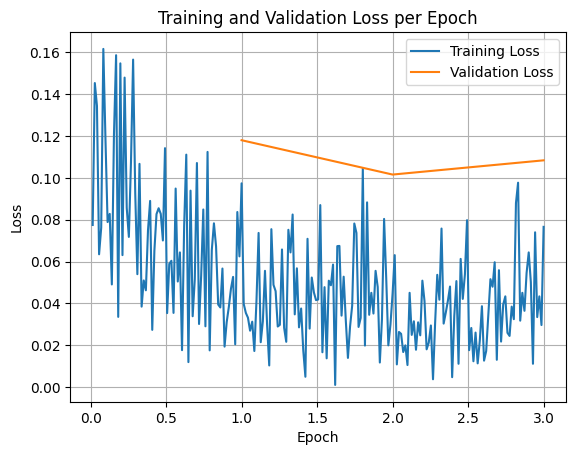

In [36]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Save the best model

We can save our best model to file using [`trl.SFTTrainer.save_model`](transformers.Trainer.save_model).


In [42]:
# Save the model
trainer.save_model()

### Optional: Remove checkpoints

When we upload our model to Hugging Face, a typical practice is to upload a certain folder (e.g. `checkpoint_models/`) including all the contents so we get the artifacts such as `config.json`, `generation_config.json`, `tokenizer.json` and more.

However, if we've got a large number of checkpoints from a training run, this could lead to uploading too many files.

In [43]:
!ls ./checkpoint_models/

added_tokens.json    config.json	      tokenizer_config.json
chat_template.jinja  generation_config.json   tokenizer.json
checkpoint-142	     model.safetensors	      tokenizer.model
checkpoint-213	     README.md		      training_args.bin
checkpoint-71	     special_tokens_map.json


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Perhaps we don't want to upload the `checkpoint-XXX` files and only the remaining files such as `model.safetensors`.

Let's remove the `checkpoint_models/checkpoint-XXX/` files and their contents.

In [63]:
# Optional: Remove all the checkpoint folders (since we've already saved the best model)
!rm -rf ./checkpoint_models/checkpoint-*/*
!rm -rf ./checkpoint_models/checkpoint-*

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [64]:
!ls checkpoint_models/

added_tokens.json	helper_functions.py	 tokenizer_config.json
chat_template.jinja	model.safetensors	 tokenizer.json
config.json		README.md		 tokenizer.model
generation_config.json	special_tokens_map.json  training_args.bin


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Much cleaner!

Let's load our fine-tuned model back in and inspect its performance on the test dataset and if it goes well, we'll upload it to the Hugging Face Hub.

## Load the trained model back in and see how it performs

We've now fine-tuned our own Gemma 3 270M to do a specific food and drink extraction task, let's load it back in and see how it performs.

In [16]:
# Load the fine-tuned model and see how it goes
from transformers import AutoTokenizer, AutoModelForCausalLM

CHECKPOINT_DIR_NAME = "./checkpoint_models"

print(f"[INFO] Loading in model from: {CHECKPOINT_DIR_NAME}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
)

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

# Check our loaded model (it's the same architecture as before except this time with updated weights)
loaded_model

[INFO] Loading in model from: ./checkpoint_models


The tokenizer you are loading from './checkpoint_models' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

Now let's create a `"text-generation"` pipeline by loading our `loaded_model` into a pipeline.

In [17]:
from transformers import pipeline

loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


### Performing inference with our fine-tuned model on the test dataset

Let's now perform inference with our fine-tuned model on a random sample from the test dataset, `dataset["test"]` (our model has never seen these samples).

If our model training went well, the outputs of our fine-tuned model should be aligned with the ground truth labels.

In [41]:
# Get a random sample
import random

random_test_idx = random.randint(0, len(dataset["test"])-1)
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=random_test_sample["prompt"],
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt, 
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output):\n{random_test_sample['gpt-oss-120b-label-condensed']}")

[INFO] Test sample input:
<bos><start_of_turn>user
A person's arm wearing a watch holds a box of beef cheeseburger dumplings. The nutrition information on the box shows 16 servings per package, with a serving size of 30g (approx. 1 dumpling). Per serve, the box contains 231 kJ of energy, 2.8g of protein, 2.1g of total fat, less than 1g of saturated fat, 6.5g of carbohydrates, less than 1g of sugars, and 109mg of sodium. The price tag above the product reads $13. Other visible products include Honey Son Chicken and various dumpling boxes.<end_of_turn>
<start_of_turn>model


[INFO] Fine-tuned model output:
food_or_drink: 1
tags: np, fi, fp
foods: beef cheeseburger dumplings, Honey Son Chicken
drinks:

[INFO] Test label (ideal output):
food_or_drink: 1
tags: np, fi, fp
foods: beef cheeseburger dumplings, Honey Son Chicken
drinks:


Nice!! Looks like our fine-tuned model is doing quite well to reproduce the target labels.

We could keep going here and inspect the predictions against the ground truth (in fact, I'd encourage you to sample at least 25 different test items and inspect them), however, let's now upload our model to the Hugging Face Hub so it's reusable.

### Testing our model on unformatted text

Machine learning models often want to predict on data in the same format they've been trained on.

For example, our model is capable of making predictions on raw text, however, it was trained to do food and drink extraction specifically on formatted text.

In [44]:
# Test the loaded model on raw text (this won't work as well as formatted text)
test_input_message_without_formatting = "Hello my name is Daniel!"
loaded_model_pipeline(test_input_message_without_formatting)

[{'generated_text': 'Hello my name is Daniel! \nfood_or_drink: 0\ntags: \nfoods: \ndrinks:'}]

Notice the model generates the same input?

What happens if we format the input?

Let's create a helper function to format our input text into message format.

In [45]:
def format_message(input):
    return [{"role": "user", "content": input}]

test_input_message_with_formatting = format_message(input=test_input_message_without_formatting)
test_input_message_with_formatting

[{'role': 'user', 'content': 'Hello my name is Daniel!'}]

Now we can turn it into a prompt with our `tokenizer` and the `apply_chat_template` method.

In [48]:
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=test_input_message_with_formatting,
                                                                   tokenize=False,
                                                                   add_generation_prompt=True)

input_prompt

'<bos><start_of_turn>user\nHello my name is Daniel!<end_of_turn>\n<start_of_turn>model\n'

Now our test input has been formatted in a style that our model has been trained on, let's test it and see how it goes.

In [47]:
loaded_model_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                             max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{loaded_model_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Hello my name is Daniel!<end_of_turn>
<start_of_turn>model


[INFO] Output:
food_or_drink: 0
tags: 
foods: 
drinks:


Excellent! Our model outputs in the exact format we were looking for! It no longer regenerates the input as it did before.

::: {.callout-tip}

The takeaway here is: if your model has been trained/fine-tuned on data in a certain format, when doing inference, always pass in data to the model in the same format its been trained on.

Otherwise, you'll likely get strange or incorrect outputs.

:::

Okay let's make another helper function to predict on any given sample input.

We'll also return the inference time of our model so we can see how long things take (a working model is one thing but if it takes too long, well then it might not be as useful as we'd like).

In [50]:
import time

def pred_on_text(input_text):
    start_time = time.time()
    
    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

example_input_text = "British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"
output_text, output_raw, output_total_time = pred_on_text(input_text=example_input_text)

print(f"[INFO] Input text:\n{example_input_text}\n")
print(f"[INFO] Model generated output text:\n{output_text}\n")
print(f"[INFO] Model full raw output:\n{output_raw}\n")
print(f"[INFO] Inference time:\n{output_total_time}\n")

[INFO] Input text:
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes

[INFO] Model generated output text:
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea

[INFO] Model full raw output:
[{'generated_text': [{'role': 'user', 'content': 'British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes'}, {'role': 'assistant', 'content': 'food_or_drink: 1\ntags: fi, di\nfoods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes\ndrinks: tea'}]}]

[INFO] Inference time:
0.6499



Outstanding!

Looks like our model is working well enough (of course we could always improve it over time with more testing and different samples).

Let's upload it to the Hugging Face Hub.

## Uploading our fine-tuned model to the Hugging Face Hub

Uploading our fine-tuned model to the Hugging Face Hub means we can easily load it in to another environment later on or share it with others so they can test it out.

To do so, we'll use the [`huggingface_hub`](https://huggingface.co/docs/huggingface_hub/en/index) library.

We'll use the [`huggingface_hub.create_repo`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.create_repo) to create a repository to store our model.

And then we can upload files/folders to our model repository using [`huggingface_hub.HfApi.upload_file`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_file) and [`huggingface_hub.HfApi.upload_folder`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_folder).

::: {.callout-note}
To use the `huggingface_hub` library, be sure to login and setup Hugging Face with a token locally or via Google Colab Secrets.

For example:

```
from huggingface_hub import login

# Run this and follow the steps
login()
```

See the [Setup guide](https://www.learnhuggingface.com/extras/setup) as well as [Hugging Face Hub documentation](https://huggingface.co/docs/hub/en/security-tokens) for more.
:::

Let's start by creating a repo, I'm going to call mine `mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1`.

My username for Hugging Face is `mrdbourke` so be sure to change it to your own.

In [61]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# Change this to your own 
HF_USERNAME = "mrdbourke" 

# Create the repo (this is in the format [Hugging Face Username]/[Target Model Name])
repo_id = f"{HF_USERNAME}/FoodExtract-gemma-3-270m-fine-tune-v1"

# Create the repo
create_repo(repo_id, 
            repo_type="model", 
            exist_ok=True)

RepoUrl('https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1')

### Create a README.md for our model

Now we'll create a `README.md` file for our model so people know how it was trained and how to use it.

Adding a README to a model is often referred to as a model card.

We can add some front matter to our [model card](https://huggingface.co/docs/hub/model-cards).

Front matter is similar to tags or metadata, it gets added in YAML format, for example:

```
---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---
```

In [66]:
model_readme = r"""---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---

# FoodExtract-v1

This is a food and drink extraction language model built on [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Given raw text, it's designed to:

1. Classify the text into food or drink (e.g. "a photo of a dog" = not food or drink, "a photo of a pizza" = food or drink).
2. Tag the text with one or more tags (see tags_dict below).
3. Extract the edible food-related items as a list.
4. Extract the edible drink-related items as a list.

For example, the input text might be:

```
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes
```

And the model will generate:

```
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea
```

This model can be used for filtering a large image caption (e.g. [DataComp-1B](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B)) text dataset for food and drink related items.

## Dataset

The model was trained on the [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.

This dataset contains 1400 samples of raw text and JSON output pairs of structured food extractions provided by `gpt-oss-120b`.

For example, a raw image caption input might be:

```
another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky
```

And the `gpt-oss-120b` generated output (JSON) would be:

```
{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}
```

This is condensed to:

```
food_or_drink: 0\ntags: \nfoods: \ndrinks:
```

### Tags dictionary mapping

These tags are designed for fast filtering.

For example, the model can assign a certain tag based on what's in the raw text and then we can filter for "ingredient list" items.

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

## Helper functions

The model is trained to output a condensed version of the structured data.

We do this so the model can generate less tokens (e.g. it doesn't have to generate JSON outputs).

The following functions help to condense and uncondense raw text outputs/inputs into the desired structure.

```python
def condense_output(original_output):
    '''Helper function to condense a given FoodExtract string.
    
    Example input: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}

    Example output: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:'''

    condensed_output_string_base = '''food_or_drink: <is_food_or_drink>
    tags: <output_tags>
    foods: <food_items>
    drinks: <drink_items>'''

    is_food_or_drink = str(1) if str(original_output["is_food_or_drink"]).lower() == "true" else str(0)
    tags = ", ".join(original_output["tags"]) if len(original_output["tags"]) > 0 else ""
    foods = ", ".join(original_output["food_items"]) if len(original_output["food_items"]) > 0 else ""
    drinks = ", ".join(original_output["drink_items"]) if len(original_output["drink_items"]) > 0 else ""

    condensed_output_string_formatted = condensed_output_string_base.replace("<is_food_or_drink>", is_food_or_drink).replace("<output_tags>", tags).replace("<food_items>", foods).replace("<drink_items>", drinks)

    return condensed_output_string_formatted.strip()

def uncondense_output(condensed_output):
    '''Helper to go from condensed output to uncondensed output.

    Example input: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:

    Example output: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}
    '''

    condensed_list = condensed_output.split("\n")

    condensed_dict_base = {
        "is_food_or_drink": "",
        "tags": [],
        "food_items": [],
        "drink_items": []
    }

    # Set values to defaults
    food_or_drink_item = None
    tags_item = None
    foods_item = None
    drinks_item = None

    # Extract items from condensed_list
    for item in condensed_list:
        if "food_or_drink:" in item.strip():
            food_or_drink_item = item

        if "tags:" in item:
            tags_item = item

        if "foods:" in item:
            foods_item = item

        if "drinks:" in item:
            drinks_item = item

    if food_or_drink_item:
        is_food_or_drink_bool = True if food_or_drink_item.replace("food_or_drink: ", "").strip() == "1" else False
    else:
        is_food_or_drink_bool = None

    if tags_item:
        tags_list = [item.replace("tags: ", "").replace("tags:", "").strip() for item in tags_item.split(", ")]
        tags_list = [item for item in tags_list if item] # Filter for empty items
    else:
        tags_list = []

    if foods_item:
        foods_list = [item.replace("foods:", "").replace("foods: ", "").strip() for item in foods_item.split(", ")]
        foods_list = [item for item in foods_list if item] # Filter for empty items
    else:
        foods_list = []

    if drinks_item:
        drinks_list = [item.replace("drinks:", "").replace("drinks: ", "").strip() for item in drinks_item.split(", ")]
        drinks_list = [item for item in drinks_list if item] # Filter for empty items
    else:
        drinks_list = []

    condensed_dict_base["is_food_or_drink"] = is_food_or_drink_bool
    condensed_dict_base["tags"] = tags_list
    condensed_dict_base["food_items"] = foods_list
    condensed_dict_base["drink_items"] = drinks_list

    return condensed_dict_base
````

## Quick start

```python
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create a sample to predict on
input_text = "A plate with bacon, eggs and toast on it"
input_text_user = [{'content': input_text, 'role': 'user'}]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=input_text_user,
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt, 
                                        max_new_tokens=256)

# View the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
```

You should see an output similar to:

```
[INFO] Test sample input:
<bos><start_of_turn>user
A plate with bacon, eggs and toast on it<end_of_turn>
<start_of_turn>model

[INFO] Fine-tuned model output:
food_or_drink: 1
tags: fi
foods: bacon, eggs, toast
drinks:
```

## Training procedure

This model was trained with SFT (Supervised Fine-Tuning) via Hugging Face's TRL library.

See the full training walkthrough at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial

## Citations

* Reference for structured data extraction was taken from the paper (tk- paper link to the paper which used a small qwen model to extract structured data from webpages)"""

# Save README to file
with open(f"{CHECKPOINT_DIR_NAME}/README.md", "w") as f:
    f.write(model_readme)

### Upload the contents of our checkpoint model folder to the Hugging Face Hub

Now we've created a model repository (repo for short) and model card, let's upload our `checkpoint_models/` folder contents to the Hugging Face Hub.

To do so, we'll use the [`upload_folder`](https://huggingface.co/docs/huggingface_hub/en/package_reference/hf_api#huggingface_hub.HfApi.upload_folder) method. 

This may take a few minutes depending on your internet connection.

In [67]:
# Upload the entire model folder containing our model files and README.md
print(f"[INFO] Uploading checkpoint directory: {CHECKPOINT_DIR_NAME} to Hugging Face repo: {repo_id}")
api.upload_folder(
    folder_path="./checkpoint_models/",
    repo_id=repo_id,
    repo_type="model"
)

[INFO] Uploading checkpoint directory: ./checkpoint_models to Hugging Face repo: mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1/commit/7656ae3f4aac29ef22443de0a6bb9d1160736a6f', commit_message='Upload folder using huggingface_hub', commit_description='', oid='7656ae3f4aac29ef22443de0a6bb9d1160736a6f', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1'), pr_revision=None, pr_num=None)

TK - UPTOHERE: making sure the model uploads well and is available ready to go on the Hugging Face Hub, add FoodExtract v2 to the list of extensions 

Woohoo! Our model is officially on the Hugging Face Hub.

You can download it here: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1/

Now not only can we redownload it and use it again, others can download it and use it for themselves (of course you can make the model private if you like too).

## Turning our model into a demo

Right now our model seems to be working quite well for our specific use case.

However, it takes some coding to be able to use it.

What if we wanted to allow someone who wasn't familiar with programming to try it out?

To do so, we can turn our model into a [Gradio](https://www.gradio.app) demo and upload it to [Hugging Face Spaces](https://huggingface.co/spaces) (a place to share all kinds of small applications).

Gradio allows us to turn our model into an easy to use and sharable demo anyone can try.

Gradio demos work on the premise of: input (text) -> function (our model) -> output (text) 

We've already go a function ready with `pred_on_text` so we can wrap this with some Gradio code.

To create a sharable demo, we'll need the following files:

* `app.py` - Entry point for our app, all of our application code will go in here.
* `README.md` - Tells people what our app does.
    * **Note:** Hugging Face Spaces use a special "front matter" (text at the start of a `README.md` file) to add various attributes to a Hugging Face Space, we'll see this below.
* `requirements.txt` - Tells Hugging Face Spaces what our app requires.
    * `torch`, `transformers`, `gradio`, `accelerate`
 
Let's make a folder to store our demo application.


In [70]:
!mkdir demos/
!mkdir demos/FoodExtract

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Creating the `app.py` file

When running our app on Hugging Face Spaces, we have the option to run our model on a GPU thanks to Hugging Face's [ZeroGPU](https://huggingface.co/docs/hub/en/spaces-zerogpu) feature. 

This is optional, however, it's highly recommend you run a model such as Gemma 3 270M on the GPU as we'll see significant speedups.

You can run a function on a GPU by importing `spaces` and then using the `@spaces.GPU` decorator on your target function.

```python
import spaces

@spaces.GPU
def function_to_run_on_the_gpu():
    pass
```

To ensure your model runs on the GPU, be sure to select a ZeroGPU instance in your Hugging Face Space settings.

In [ ]:
%%writefile demos/FoodExtract/app.py

# Load dependencies
import time
import transformers
import torch
import spaces # Optional: run our model on the GPU (this will be much faster inference)

import gradio as gr

from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import pipeline

@spaces.GPU # Optional: run our model on the GPU (this will be much faster inference)
def pred_on_text(input_text):
    start_time = time.time()
    
    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

# Load the model (from our Hugging Face Repo)
# Note: You may have to replace my username `mrdbourke` for your own
MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create the demo
description = """Extract food and drink items from text with a fine-tuned SLM (Small Language Model) or more specifically a fine-tuned [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Our model has been fine-tuned on the [FoodExtract-1k dataset](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k). 

* Input (str): Raw text strings or image captions (e.g. "A photo of a dog sitting on a beach" or "A breakfast plate with bacon, eggs and toast")
* Output (str): Generated text with food/not_food classification as well as noun extracted food and drink items and various food tags.

For example:

* Input: "For breakfast I had eggs, bacon and toast and a glass of orange juice"
* Output: 

```
food_or_drink: 1
tags: fi, di
foods: eggs, bacon, toast
drinks: orange juice
```
"""

demo = gr.Interface(fn=pred_on_text,
                    inputs=gr.TextArea(lines=4, label="Input Text"),
                    outputs=[gr.TextArea(lines=4, label="Generated Text"),
                             gr.TextArea(lines=7, label="Raw Output"),
                             gr.Number(label="Generation Time (s)")],
                    title="🍳 Structured FoodExtract with a Fine-Tuned Gemma 3 270M",
                    description=description,
                    examples=[["Hello world! This is my first fine-tuned LLM!"],
                              ["A plate of food with grilled barramundi, salad with avocado, olives, tomatoes and Italian dressing"],
                              ["British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"],
                              ["Steak tacos"],
                              ["A photo of a dog sitting on a beach"]]
)

if __name__ == "__main__":
    demo.launch(share=False)


Writing demos/FoodExtract/app.py


### Create the `README.md` file

The `README.md` file will tell people what our app does.

We could add more information here if we wanted to but for now we'll keep it simple.

Notice the special text at the top of the file below (the text between the `---`), these are some settings for the Space, you can see the [settings for these in the docs](https://huggingface.co/docs/hub/en/spaces-config-reference).

In [75]:
%%writefile demos/FoodExtract/README.md
---
title: FoodExtract Fine-tuned LLM Structued Data Extractor
emoji: 📝➡️🍟
colorFrom: green
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

"""
Fine-tuned Gemma 3 270M to extract food and drink items from raw text.

Input can be any form of real text and output will be a formatted string such as the following:

```
food_or_drink: 1
tags: fi, re
foods: tacos, milk, red apple, pineapple, cherries, fried chicken, steak, mayonnaise
drinks: iced latte, matcha latte
```

The tags map to the following items:

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

You can see walkthrough step by step code details at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial 
"""

Overwriting demos/FoodExtract/README.md


### Create the `requirements.txt` file

This will tell the Hugging Face Space what libraries we'd like it to run inside.

In [76]:
%%writefile demos/FoodExtract/requirements.txt
transformers
gradio
torch
accelerate

Overwriting demos/FoodExtract/requirements.txt


### Upload our demo to the Hugging Face Hub

We can upload our demo to the Hugging Face Hub in a similar way to uploading our model.

We could also upload it file by file via the Hugging Face Spaces interface.

But let's stick to the code-first approach.

In [77]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading multiple files (in a folder)
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demos/FoodExtract/"
HF_TARGET_SPACE_NAME = "FoodExtract-v1"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub 
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists 
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading FoodExtract demo app.py"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on Hugging Face Hub with name: FoodExtract-v1
[INFO] Full Hugging Face Hub repo name: mrdbourke/FoodExtract-v1
[INFO] Uploading demos/FoodExtract/ to repo: mrdbourke/FoodExtract-v1
[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/mrdbourke/FoodExtract-v1/tree/main/.


Nice!

It looks like our demo upload worked!

We can try it out via the URL (in my case, it's: [https://huggingface.co/spaces/mrdbourke/FoodExtract-v1](https://huggingface.co/spaces/mrdbourke/FoodExtract-v1)). And we can even embed it right in our notebook.

In [78]:
from IPython.display import HTML

html_code = """<iframe
	src="https://mrdbourke-foodextract-v1.hf.space"
	frameborder="0"
	width="850"
	height="1000"
></iframe>"""

display(HTML(html_code))

How cool!

We've now got a sharable demo of a fine-tuned LLM which anyone can try out for themselves.

## Bonus: Speeding up our model with batched inference

Right now our model only inferences on one sample at a time but as is the case with many machine learning models, we could perform inference on multiple samples (also referred to as a batch) to significantly improve throughout.

In batched inference mode, your model performs predictions on X number of samples at once, this can dramatically improve sample throughput.

The number of samples you can predict on at once will depend on a few factors: 

* The size of your model (e.g. if your model is quite large, it may only be able to predict on 1 sample at time)
* The size of your compute VRAM (e.g. if your compute VRAM is already saturated, add multiple samples at a time may result in errors)
* The size of your samples (if one of your samples is 100x the size of others, this may cause errors with batched inference)

To find an optimal batch size for our setup, we can run an experiment:

* Loop through different batch sizes and measure the throughput for each batch size.
    * Why do we do this?
        * It's hard to tell the ideal batch size ahead of time.
        * So we experiment from say 1, 2, 4, 8, 16, 32, 64 batch sizes and see which performs best.
        * Just because we may get a speed up from using batch size 8, doesn't mean 64 will be better. 

In [51]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

def sample_to_conversation(sample):
    return {
        "messages": [
            {"role": "user", "content": sample["sequence"]}, # Load the sequence from the dataset
            {"role": "system", "content": sample["gpt-oss-120b-label-condensed"]} # Load the gpt-oss-120b generated label
        ]
    }

# Map our sample_to_conversation function to dataset 
dataset = dataset.map(sample_to_conversation,
                      batched=False)

# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world
dataset

[INFO] Number of samples in the dataset: 1420


DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'messages'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'messages'],
        num_rows: 284
    })
})

In [52]:
# Step 1: Need to turn our samples into batches (e.g. lists of samples)
print(f"[INFO] Formatting test samples into list prompts...")
test_input_prompts = [
    loaded_model_pipeline.tokenizer.apply_chat_template(
        item["messages"][:1],
        tokenize=False,
        add_generation_prompt=True
    )
    for item in dataset["test"]
]
print(f"[INFO] Number of test sample prompts: {len(test_input_prompts)}")
test_input_prompts[0]

[INFO] Formatting test samples into list prompts...
[INFO] Number of test sample prompts: 284


'<bos><start_of_turn>user\nLiving Planet Goat Milk Whole Milk, 1 Litre, GMO Free, Australian Dairy, 8.75g Protein Per Serve, Good Source of Calcium.<end_of_turn>\n<start_of_turn>model\n'

In [53]:
# Step 2: Need to perform batched inference and time each step
import time
from tqdm.auto import tqdm

all_outputs = []

# Let's write a list of batch sizes to test
chunk_sizes_to_test = [1, 4, 8, 16, 32, 64, 128]
timing_dict = {}

# Loop through each batch size and time the inference
for CHUNK_SIZE in chunk_sizes_to_test:
    print(f"[INFO] Making predictions with batch size: {CHUNK_SIZE}")
    start_time = time.time()

    for chunk_number in tqdm(range(round(len(test_input_prompts) / CHUNK_SIZE))):
        batched_inputs = test_input_prompts[(CHUNK_SIZE * chunk_number): CHUNK_SIZE * (chunk_number + 1)]
        batched_outputs = loaded_model_pipeline(text_inputs=batched_inputs,
                                                batch_size=CHUNK_SIZE,
                                                max_new_tokens=256,
                                                disable_compile=True)
        
        all_outputs += batched_outputs
    
    end_time = time.time()
    total_time = end_time - start_time
    timing_dict[CHUNK_SIZE] = total_time
    print()
    print(f"[INFO] Total time for batch size {CHUNK_SIZE}: {total_time:.2f}s")
    print("="*80 + "\n\n")

[INFO] Making predictions with batch size: 1


  0%|          | 0/284 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[INFO] Total time for batch size 1: 144.40s


[INFO] Making predictions with batch size: 4


  0%|          | 0/71 [00:00<?, ?it/s]

...


[INFO] Total time for batch size 32: 33.65s


[INFO] Making predictions with batch size: 64


  0%|          | 0/4 [00:00<?, ?it/s]


[INFO] Total time for batch size 64: 31.30s


[INFO] Making predictions with batch size: 128


  0%|          | 0/2 [00:00<?, ?it/s]


[INFO] Total time for batch size 128: 48.09s




Batched inference complete! Let's make a plot comparing different batch sizes.

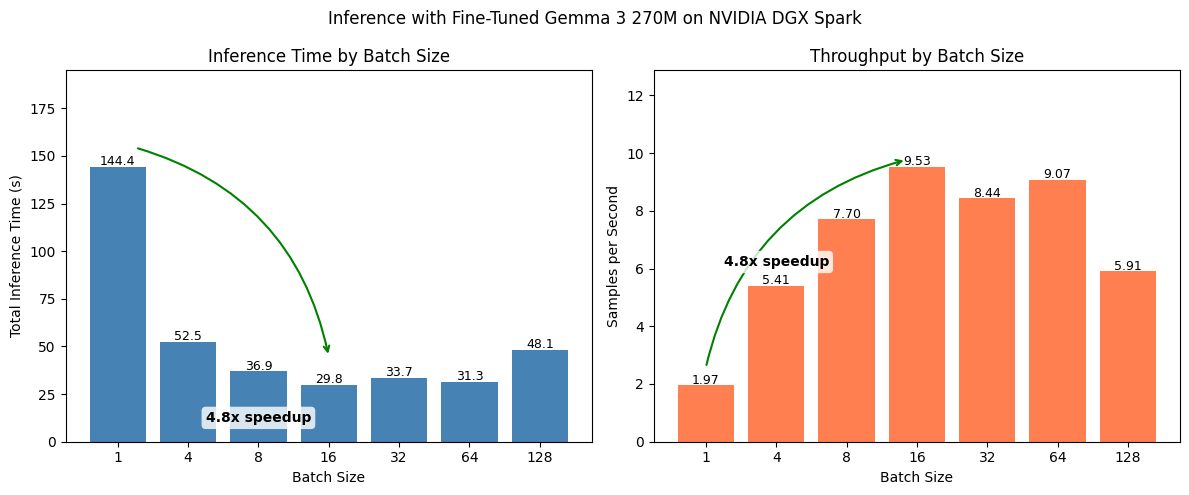

In [54]:
import matplotlib.pyplot as plt

# Data
data = timing_dict

total_samples = len(dataset["test"])

batch_sizes = list(data.keys())
inference_times = list(data.values())
samples_per_second = [total_samples / time for bs, time in data.items()]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: Total Inference Time ---
ax1.bar([str(bs) for bs in batch_sizes], inference_times, color='steelblue')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Total Inference Time (s)')
ax1.set_title('Inference Time by Batch Size')

for i, v in enumerate(inference_times):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Left) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val = max(inference_times)
end_val = min(inference_times)
start_idx = inference_times.index(start_val)
end_idx = inference_times.index(end_val)

speedup = start_val / end_val

# 2. Draw Arrow (No Text)
# connectionstyle "rad=-0.3" arcs the arrow upwards
ax1.annotate("",
             xy=(end_idx, end_val+(0.5*end_val)),
             xytext=(start_idx+0.25, start_val+10),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x = (start_idx + end_idx) / 2
# Place text slightly above the highest point of the two bars
text_y = max(start_val, end_val) + (max(inference_times) * 0.1)

ax1.text(mid_x+0.5, text_y-150, f"{speedup:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax1.set_ylim(0, max(inference_times) * 1.35) # Increase headroom for text


# --- Right plot: Samples per Second ---
ax2.bar([str(bs) for bs in batch_sizes], samples_per_second, color='coral')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Samples per Second')
ax2.set_title('Throughput by Batch Size')

for i, v in enumerate(samples_per_second):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Right) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val_t = min(samples_per_second)
end_val_t = max(samples_per_second)
start_idx_t = samples_per_second.index(start_val_t)
end_idx_t = samples_per_second.index(end_val_t)

speedup_t = end_val_t / start_val_t

# 2. Draw Arrow (No Text)
ax2.annotate("",
             xy=(end_idx_t-(0.05*end_idx_t), end_val_t+(0.025*end_val_t)),
             xytext=(start_idx_t, start_val_t+0.6),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x_t = (start_idx_t + end_idx_t) / 2
text_y_t = max(start_val_t, end_val_t) + (max(samples_per_second) * 0.1)

ax2.text(mid_x_t-0.5, text_y_t-4.5, f"{speedup_t:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax2.set_ylim(0, max(samples_per_second) * 1.35) # Increase headroom

plt.suptitle("Inference with Fine-Tuned Gemma 3 270M on NVIDIA DGX Spark")
plt.tight_layout()
plt.savefig('inference_benchmark.png', dpi=150)
plt.show()

We get a 4-6x speedup when using batches!

At 10 samples per second, that means we can inference on ~800k samples in a day.

In [62]:
samples_per_second = round(len(dataset["test"]) / min(timing_dict.values()), 2)
seconds_in_a_day = 86_400
samples_per_day = seconds_in_a_day * samples_per_second

print(f"[INFO] Number of samples per second: {samples_per_second} | Number of samples per day: {samples_per_day}")

[INFO] Number of samples per second: 9.53 | Number of samples per day: 823392.0


## TK - Bonus: Performing evaluations on our model

We can evaluate our model directly against the original labels from `gpt-oss-120b` and see how it stacks up.

For example, we could compare the following:

* F1 Score
* Precision
* Recall
* Pure accuracy

Have these metrics as well as samples which are different to the ground truth would allow us to further explore where our model needs improvements.

In [ ]:
len(dataset["test"]["sequence"])

In [ ]:
input_test_prompts_formatted = [{"role": "user", "content": item} for item in dataset["test"]["sequence"]]
input_test_prompts_no_format = [item for item in dataset["test"]["sequence"]]
len(input_test_prompts_no_format)

In [ ]:
# Get preds on the test set
test_outputs = []

for item in tqdm(dataset["test"]):
  prompt = pipe.tokenizer.apply_chat_template(item["messages"][:1], tokenize=False, add_generation_prompt=True)
  outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

  item["test_outputs"] = outputs
  test_outputs.append(item)

### Helper functions for condensing and uncondensing items

In [55]:
%%writefile checkpoint_models/helper_functions.py
def condense_output(original_output):
    """Helper function to condense a given FoodExtract string.
    
    Example input: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}

    Example output: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:"""

    condensed_output_string_base = '''food_or_drink: <is_food_or_drink>
    tags: <output_tags>
    foods: <food_items>
    drinks: <drink_items>'''

    is_food_or_drink = str(1) if str(original_output["is_food_or_drink"]).lower() == "true" else str(0)
    tags = ", ".join(original_output["tags"]) if len(original_output["tags"]) > 0 else ""
    foods = ", ".join(original_output["food_items"]) if len(original_output["food_items"]) > 0 else ""
    drinks = ", ".join(original_output["drink_items"]) if len(original_output["drink_items"]) > 0 else ""

    condensed_output_string_formatted = condensed_output_string_base.replace("<is_food_or_drink>", is_food_or_drink).replace("<output_tags>", tags).replace("<food_items>", foods).replace("<drink_items>", drinks)

    return condensed_output_string_formatted.strip()

def uncondense_output(condensed_output):
    """Helper to go from condensed output to uncondensed output.

    Example input: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:

    Example output: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}
    """

    condensed_list = condensed_output.split("\n")

    condensed_dict_base = {
        "is_food_or_drink": "",
        "tags": [],
        "food_items": [],
        "drink_items": []
    }

    # Set values to defaults
    food_or_drink_item = None
    tags_item = None
    foods_item = None
    drinks_item = None

    # Extract items from condensed_list
    for item in condensed_list:
        if "food_or_drink:" in item.strip():
            food_or_drink_item = item

        if "tags:" in item:
            tags_item = item

        if "foods:" in item:
            foods_item = item

        if "drinks:" in item:
            drinks_item = item

    if food_or_drink_item:
        is_food_or_drink_bool = True if food_or_drink_item.replace("food_or_drink: ", "").strip() == "1" else False
    else:
        is_food_or_drink_bool = None

    if tags_item:
        tags_list = [item.replace("tags: ", "").replace("tags:", "").strip() for item in tags_item.split(", ")]
        tags_list = [item for item in tags_list if item] # Filter for empty items
    else:
        tags_list = []

    if foods_item:
        foods_list = [item.replace("foods:", "").replace("foods: ", "").strip() for item in foods_item.split(", ")]
        foods_list = [item for item in foods_list if item] # Filter for empty items
    else:
        foods_list = []

    if drinks_item:
        drinks_list = [item.replace("drinks:", "").replace("drinks: ", "").strip() for item in drinks_item.split(", ")]
        drinks_list = [item for item in drinks_list if item] # Filter for empty items
    else:
        drinks_list = []

    condensed_dict_base["is_food_or_drink"] = is_food_or_drink_bool
    condensed_dict_base["tags"] = tags_list
    condensed_dict_base["food_items"] = foods_list
    condensed_dict_base["drink_items"] = drinks_list

    return condensed_dict_base

Writing checkpoint_models/helper_functions.py


In [ ]:
# Test them out
import random

random_test_sample = random.choice(test_outputs)
random_test_sequence = random_test_sample["sequence"]
random_test_original_label = random_test_sample["gpt-oss-120b-label"]
random_test_predicted_label_condensed = random_test_sample["test_outputs"][0]["generated_text"].split("<start_of_turn>model")[-1].strip()

print(f"[INFO] Original sequence:")
print(random_test_sequence)
print()
print(f"[INFO] GPT-OSS-120B label:")
print(random_test_original_label)
print()
print(f"[INFO] Uncondensed output:")
print(uncondense_output(random_test_predicted_label_condensed))
print()
print(f"[INFO] Condensed output:")
print(random_test_predicted_label_condensed)

In [ ]:
for item in test_outputs:
  item["condensed_output"] = uncondense_output(item["test_outputs"][0]["generated_text"].split("<start_of_turn>model")[-1].strip())

In [ ]:
random_test_sample = random.choice(test_outputs)
random_test_sequence = random_test_sample["sequence"]
random_test_original_label = random_test_sample["gpt-oss-120b-label"]
random_test_predicted_label = random_test_sample["condensed_output"]

print(f"[INFO] Original sequence:")
print(random_test_sequence)
print()
print(f"[INFO] GPT-OSS-120B label:")
print(random_test_original_label)
print()
print(f"[INFO] Uncondensed output:")
print(random_test_predicted_label)
print()

In [ ]:
# Quick evals

# Get pure equality matching (e.g. strict field to field)
num_bool_matches = 0
num_tags_matches = 0
num_food_items_matches = 0
num_drink_items_matches = 0

for item in test_outputs:
  gpt_labels = eval(item["gpt-oss-120b-label"])
  gemma_labels = item["condensed_output"]

  for key, value in gpt_labels.items():
    is_match = 1 if gemma_labels[key] == value else 0

    if key == "is_food_or_drink":
      num_bool_matches += is_match

    if key == "tags":
      num_tags_matches += is_match

    if key == "food_items":
      num_food_items_matches += is_match

    if key == "drink_items":
      num_drink_items_matches += is_match

print(f"[INFO] Number of direct bool matches: {num_bool_matches}/{len(test_outputs)}")
print(f"[INFO] Number of direct tag matches: {num_tags_matches}/{len(test_outputs)}")
print(f"[INFO] Number of direct food items matches: {num_food_items_matches}/{len(test_outputs)}")
print(f"[INFO] Number of direct drink items matches: {num_drink_items_matches}/{len(test_outputs)}")

### More specific evals

Going to expand on the quick evals and see where we get to.

Details:

* For precision and recall we require true positives, false positives and false negatives:
  * **True positives:** Items in both the target set as well as the predicted set.
  * **False positives:** Items in the predicted set but *not* in the target set.
  * **False negatives:** Items in the target set but *not* in the predicted set.

In [ ]:
# Get pure equality matching (e.g. strict field to field)
num_bool_matches = 0
num_tags_matches = 0
num_food_items_matches = 0
num_food_items_filter_matches = 0
num_drink_items_matches = 0
num_drink_items_filter_matches = 0

def make_sure_bool_is_str(input):
  if isinstance(input, bool):
    input = str(input).lower()
    input = "true" if "true" in input else "false"
    return input
  else:
    input = str(input).lower()
    input = "true" if "true" in input else "false"
    return input

result_dicts = []
for item in test_outputs:
  result_dict = {}

  gpt_labels = eval(item["gpt-oss-120b-label"])
  gemma_labels = item["condensed_output"]

  result_dict["gpt_labels"] = gpt_labels
  result_dict["gemma_labels"] = gemma_labels
  result_dict["sequence"] = item["sequence"]
  result_dict["uuid"] = item["uuid"]

  # Make sure the types of the bools are the same (we just want all strings)
  gpt_labels["is_food_or_drink"] = make_sure_bool_is_str(input=gpt_labels["is_food_or_drink"])
  gemma_labels["is_food_or_drink"] = make_sure_bool_is_str(input=gemma_labels["is_food_or_drink"])

  for key, value in gpt_labels.items():
    # Get truth labels
    gpt_truth = value
    gemma_truth = gemma_labels[key]

    # Find direct matches
    is_match = 1 if gpt_truth == gemma_truth else 0

    # Go through individual stats and see if there are matches
    if key == "is_food_or_drink":
      result_dict["results_is_food_or_drink_match"] = True if gpt_truth == gemma_truth else False
      num_bool_matches += is_match

    if key == "tags":
      result_dict["results_tags_match"] = True if gpt_truth == gemma_truth else False
      num_tags_matches += is_match

    if key == "food_items":
      result_dict["results_food_items_match"] = True if gpt_truth == gemma_truth else False
      num_food_items_matches += is_match

      # Compare samples with lowering and filtering for uniques
      gpt_food_list_lower = sorted(set([item.lower() for item in gpt_truth]))
      gemma_food_list_lower = sorted(set([item.lower() for item in gemma_truth]))

      # Match filtered and set labels (removes duplicates)
      if gpt_food_list_lower == gemma_food_list_lower:
        num_food_items_filter_matches += 1
        result_dict["result_food_items_filter_match"] = True
      else:
        result_dict["result_food_items_filter_match"] = False

      # Get items that are predicted by Gemma but aren't in the labels (False Positive)
      food_list_false_positive = set(gemma_food_list_lower) - set(gpt_food_list_lower)
      result_dict["result_food_list_false_positive"] = food_list_false_positive

      # Get items that are in GPT labels but aren't predicted by Gemma (False Negative)
      food_list_true_negative = set(gpt_food_list_lower) - set(gemma_food_list_lower)
      result_dict["result_food_list_false_negative"] = food_list_true_negative

    if key == "drink_items":
      result_dict["results_drink_items_match"] = True if gpt_truth == gemma_truth else False
      num_drink_items_matches += is_match

      # Compare samples with lowering and filtering for uniques
      gpt_drink_list_lower = sorted(set([item.lower() for item in gpt_truth]))
      gemma_drink_list_lower = sorted(set([item.lower() for item in gemma_truth]))

      # Match filtered and set labels (removes duplicates)
      if gpt_drink_list_lower == gemma_drink_list_lower:
        num_drink_items_filter_matches += 1
        result_dict["result_drink_items_filter_match"] = True
      else:
        result_dict["result_drink_items_filter_match"] = False

      # Get items that are predicted by Gemma but aren't in the labels (False Positives)
      drink_list_false_positive = set(gemma_drink_list_lower) - set(gpt_drink_list_lower)
      result_dict["result_drink_list_false_positive"] = drink_list_false_positive

      # Get items that are in GPT labels but aren't predicted by Gemma (False Negatives)
      drink_list_true_negative = set(gpt_drink_list_lower) - set(gemma_drink_list_lower)
      result_dict["result_drink_list_false_negative"] = drink_list_true_negative

  result_dicts.append(result_dict)

print(f"[INFO] Number of direct bool matches: {num_bool_matches}/{len(test_outputs)} ({num_bool_matches / len(test_outputs) * 100:.2f}%)")
print(f"[INFO] Number of direct tag matches: {num_tags_matches}/{len(test_outputs)} ({num_tags_matches / len(test_outputs) * 100:.2f}%)")
print(f"[INFO] Number of direct food items matches: {num_food_items_matches}/{len(test_outputs)} ({num_food_items_matches / len(test_outputs) * 100:.2f}%)")
print(f"[INFO] Number of filtered food items matches: {num_food_items_filter_matches}/{len(test_outputs)} ({num_food_items_filter_matches / len(test_outputs) * 100:.2f}%)")
print(f"[INFO] Number of direct drink items matches: {num_drink_items_matches}/{len(test_outputs)} ({num_drink_items_matches / len(test_outputs) * 100:.2f}%)")

In [ ]:
# Examples
gpt_food = ['wheat flour', 'vegetable oil', 'salt', 'sugar', 'water']
gemma_food = ['wheat flour', 'vegetable oil', 'salt', 'milk', 'vanilla']

def filter_and_lower_list(input_list):
  """Filters a list for uniques and lowers all inputs."""
  if len(input_list) > 0:
    return sorted(set([str(item.lower()) for item in input_list]))
  else:
    return input_list

def calculate_precision_recall_f1(reference, predicted):
  """Calculates precision, recall and F1 scores for two given lists."""

  # Filter items for best comparison
  reference = filter_and_lower_list(input_list=reference)
  predicted = filter_and_lower_list(input_list=predicted)

  # Ensure they're both sets for easy comparison
  ref_set = set(reference)
  pred_set = set(predicted)

  # Handle case where there are empty lists, in this case, the empty predictions are correct
  if (len(ref_set) == 0) and (len(pred_set) == 0):
    precision = 1.0
    recall = 1.0
    f1_score = 1.0

  else:
    # Get TP (True Positives)
    tp = len(ref_set & pred_set) # intersection

    # Get FP (False Positives)
    fp = len(pred_set - ref_set) # items only in predicted but not in reference

    # Get FN (False Negatives)
    fn = len(ref_set - pred_set) # items only in reference but not in predicted

    # Calculate metrics
    # Precision = fp / (tp + fp) - higher precision = less false positives
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Recall = tp / (tp + fn) - higher recall = less false negatives
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # F1 (combined metric for precision and recall) = 2 * precision * recall / (precision + recall)
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

  # Return a dict of metrics
  return {
      "precision": precision,
      "recall": recall,
      "f1_score": f1_score,
      "intersection": list(ref_set.intersection(pred_set)),
      "only_in_reference": list(ref_set - pred_set),
      "only_in_pred": list(pred_set - ref_set)
  }

calculate_precision_recall_f1(reference=gpt_food,
                              predicted=gemma_food)

### Calculate precision and recall metrics across all fields

In [ ]:
tags_precision = 0
tags_recall = 0
tags_f1 = 0

food_precision = 0
food_recall = 0
food_f1 = 0

drink_recall = 0
drink_precision = 0
drink_f1 = 0

for item in result_dicts:
  tags_metrics = item["tag_metrics"]
  tags_precision += tags_metrics["precision"]
  tags_recall += tags_metrics["recall"]
  tags_f1 += tags_metrics["f1_score"]

  food_metrics = item["food_metrics"]
  food_precision += food_metrics["precision"]
  food_recall += food_metrics["recall"]
  food_f1 += food_metrics["f1_score"]

  drink_metrics = item["drink_metrics"]
  drink_precision += drink_metrics["precision"]
  drink_recall += drink_metrics["recall"]
  drink_f1 += drink_metrics["f1_score"]

print(f"[INFO] Tags metrics:")
print(f"Precision: {tags_precision / len(result_dicts):.3f}")
print(f"Recall: {tags_recall / len(result_dicts):.3f}")
print(f"F1: {tags_f1 / len(result_dicts):.3f}")
print()

print(f"[INFO] Food metrics:")
print(f"Precision: {food_precision / len(result_dicts):.3f}")
print(f"Recall: {food_recall / len(result_dicts):.3f}")
print(f"F1: {food_f1 / len(result_dicts):.3f}")
print()

print(f"[INFO] Drink metrics:")
print(f"Precision: {drink_precision / len(result_dicts):.3f}")
print(f"Recall: {drink_recall / len(result_dicts):.3f}")
print(f"F1: {drink_f1 / len(result_dicts):.3f}")
print()

## Next steps

There are several avenues we could approach next.

1. Improve the data sampling - if our model makes mistakes, could we improve the input data? For example, more samples on certain tasks where the model is weaker.

2. Quantisation - right now our model is ~500MB, could we make this smaller with the help of INT8 quantisation? (this could also help speed up inference time)

3. Output compression - our output is compressed to a simple YAML-like format, but is there a better compression option to generate even less tokens?

4. Test the model on a large unseen sample - practice using the model on a large corpus of image captions (e.g. 10,000+) and randomly inspect them to find failure cases to boost the model performance
